# Reducción de Dimensionalidad con UMAP
## Dataset: Hotel Bookings

**UMAP** (Uniform Manifold Approximation and Projection) proyecta datos de alta
dimensionalidad a 2D o 3D preservando tanto la estructura local como la global.
Es más rápido que t-SNE y, a diferencia de este, soporta proyectar nuevos datos
una vez ajustado el modelo.

### UMAP vs t-SNE
| | t-SNE | UMAP |
|-|-------|------|
| Velocidad | Lento | Rápido |
| Estructura global | Débil | Mejor preservada |
| Proyectar nuevos datos | No | Sí (`transformar()`) |
| Parámetro principal | Perplejidad | n_vecinos + distancia_minima |

### Flujo de trabajo
```
mf.UMAP(path, num)          # 1. Cargar datos
    ↓ métodos EDA heredados  # 2. Limpiar y preparar
umap.ajustar()              # 3. Calcular proyección
umap.plot_proyeccion()      # 4. Visualizar
```

## 1. Importación de librerías

In [1]:
import sys
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
import pckEDA as mf

%matplotlib inline
print('Clase UMAP disponible:', mf.UMAP)

Clase UMAP disponible: <class 'pckEDA.no_supervisado.umap.UMAP'>


## 2. Carga de datos

In [2]:
umap = mf.UMAP('../datasets/hotel_bookings.csv', 1, n_componentes=2, n_vecinos=15, distancia_minima=0.1)

umap.mostrarTamaño()
umap.muestraTiposDeDatos()

Tamaño del DataFrame: (408, 20)
hotel                              str
is_canceled                      int64
lead_time                        int64
arrival_date_month                 str
stays_in_weekend_nights          int64
                                ...   
customer_type                      str
adr                            float64
required_car_parking_spaces      int64
total_of_special_requests        int64
reservation_status                 str
Length: 20, dtype: object


## 3. Preprocesamiento con métodos heredados del EDA

In [3]:
umap.codificarCategorica('hotel')
umap.codificarCategorica('arrival_date_month')
umap.codificarCategorica('assigned_room_type')
umap.codificarCategorica('deposit_type', mapeo={'No Deposit': 0, 'Non Refund': 1, 'Refundable': 2})
umap.codificarCategorica('customer_type')
umap.codificarCategorica('reservation_status')
umap.eliminarDuplicados()
umap.eliminarNulos()
umap.analisisNumerico()
print(f'Observaciones para la proyección: {len(umap.df)}')

Columna 'hotel' codificada con el mapeo:
  City Hotel → 0
  Resort Hotel → 1
Columna 'arrival_date_month' codificada con el mapeo:
  April → 0
  August → 1
  February → 2
  January → 3
  July → 4
  June → 5
  March → 6
  May → 7
Columna 'assigned_room_type' codificada con el mapeo:
  A → 0
  B → 1
  C → 2
  D → 3
  E → 4
  F → 5
  G → 6
  H → 7
  I → 8
  K → 9
Columna 'deposit_type' codificada con el mapeo:
  No Deposit → 0
  Non Refund → 1
  Refundable → 2
Columna 'customer_type' codificada con el mapeo:
  Contract → 0
  Group → 1
  Transient → 2
  Transient-Party → 3
Columna 'reservation_status' codificada con el mapeo:
  Canceled → 0
  Check-Out → 1
  No-Show → 2
Se eliminaron 13 filas duplicadas. Total actual: 395 filas.
Valores nulos antes: 0 en 395 filas.
hotel                          0
is_canceled                    0
lead_time                      0
arrival_date_month             0
stays_in_weekend_nights        0
                              ..
customer_type                 

## 4. Ajuste del modelo UMAP

In [4]:
umap.ajustar()

print(f'n_vecinos         : {umap.n_vecinos}')
print(f'distancia_minima  : {umap.distancia_minima}')
print(f'métrica           : {umap.metrica}')
print(f'Dimensiones       : {umap.n_componentes}')
print(f'Shape proyección  : {umap.coordenadas.shape}')

n_vecinos         : 15
distancia_minima  : 0.1
métrica           : euclidean
Dimensiones       : 2
Shape proyección  : (395, 2)


## 5. Proyección sin etiquetas

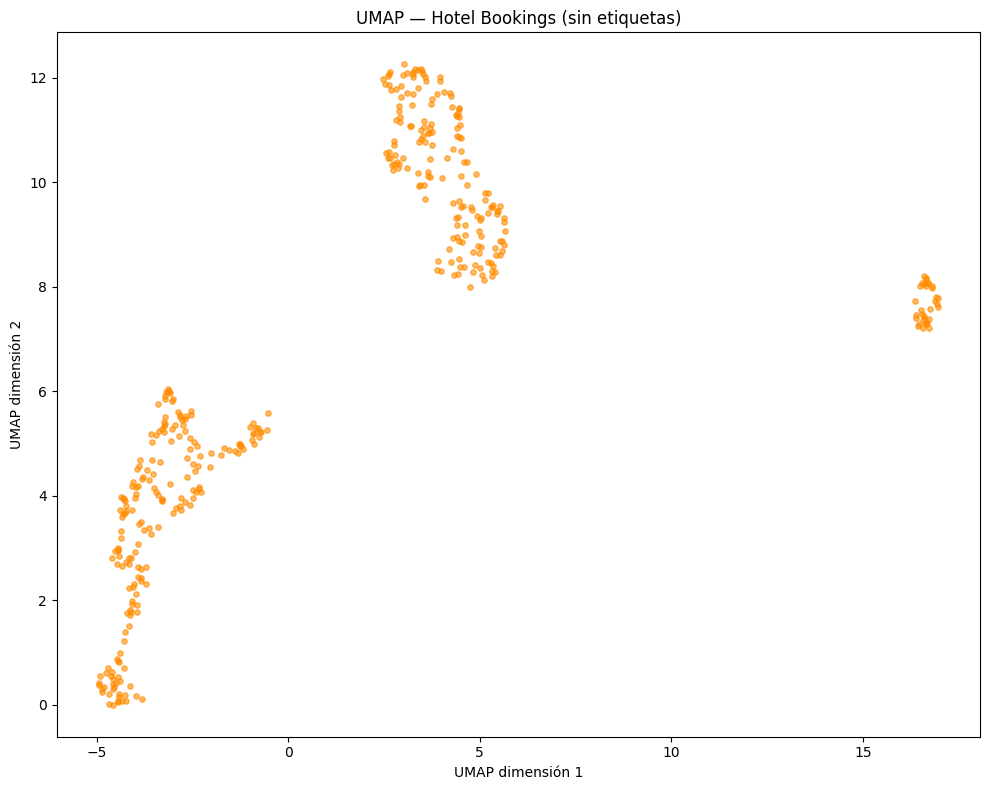

In [5]:
plt.figure(figsize=(10, 8))
umap.plot_proyeccion(titulo='UMAP — Hotel Bookings (sin etiquetas)')
plt.tight_layout()
plt.show()

## 6. Proyección coloreada con clusters de HAC

Columna 'hotel' codificada con el mapeo:
  City Hotel → 0
  Resort Hotel → 1
Columna 'arrival_date_month' codificada con el mapeo:
  April → 0
  August → 1
  February → 2
  January → 3
  July → 4
  June → 5
  March → 6
  May → 7
Columna 'assigned_room_type' codificada con el mapeo:
  A → 0
  B → 1
  C → 2
  D → 3
  E → 4
  F → 5
  G → 6
  H → 7
  I → 8
  K → 9
Columna 'deposit_type' codificada con el mapeo:
  No Deposit → 0
  Non Refund → 1
  Refundable → 2
Columna 'customer_type' codificada con el mapeo:
  Contract → 0
  Group → 1
  Transient → 2
  Transient-Party → 3
Columna 'reservation_status' codificada con el mapeo:
  Canceled → 0
  Check-Out → 1
  No-Show → 2
Se eliminaron 13 filas duplicadas. Total actual: 395 filas.
Valores nulos antes: 0 en 395 filas.
hotel                          0
is_canceled                    0
lead_time                      0
arrival_date_month             0
stays_in_weekend_nights        0
                              ..
customer_type                 

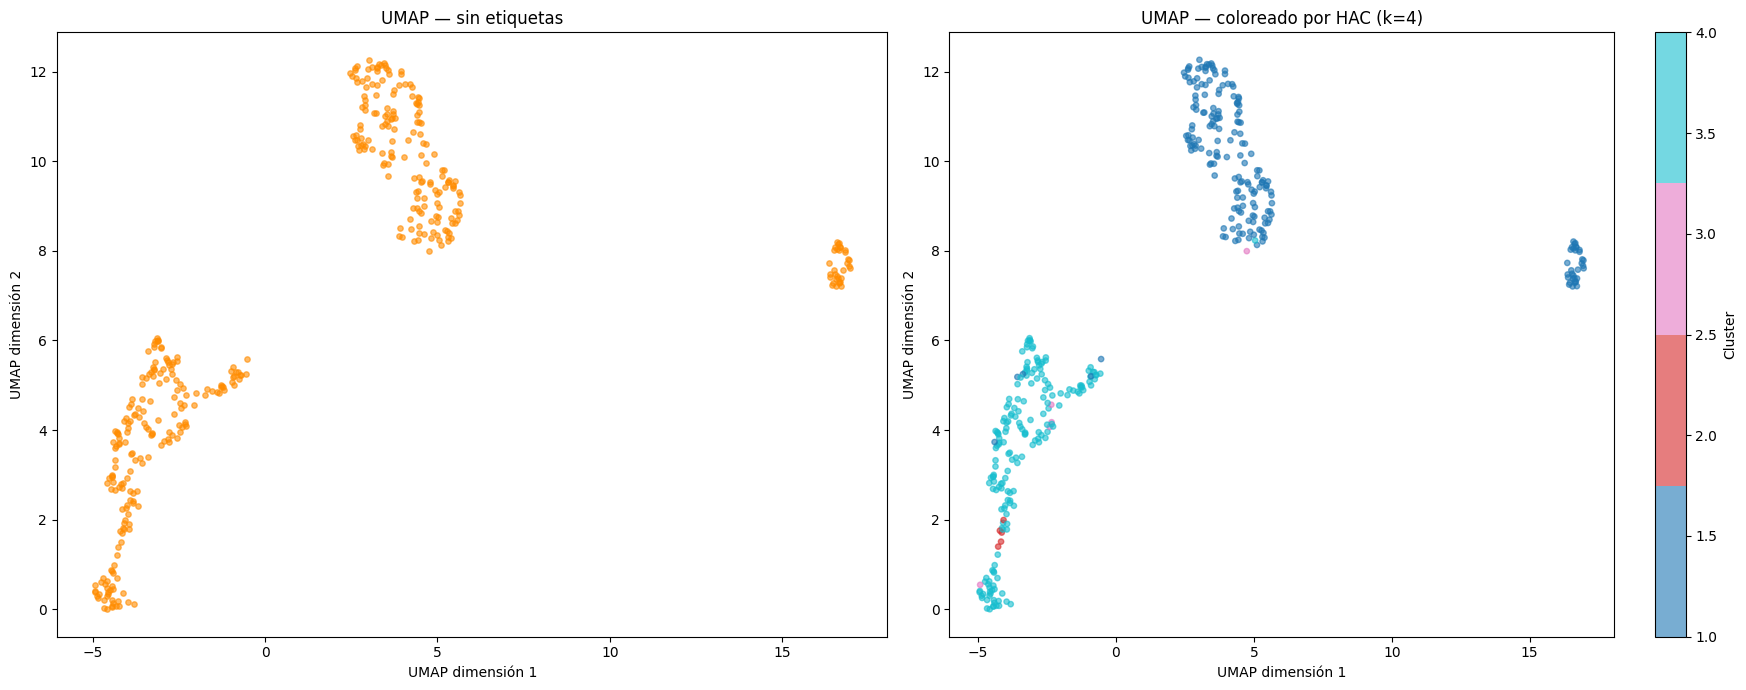

In [6]:
hac = mf.HAC('../datasets/hotel_bookings.csv', 1, n_clusters=4, metodo='ward')
hac.codificarCategorica('hotel')
hac.codificarCategorica('arrival_date_month')
hac.codificarCategorica('assigned_room_type')
hac.codificarCategorica('deposit_type', mapeo={'No Deposit': 0, 'Non Refund': 1, 'Refundable': 2})
hac.codificarCategorica('customer_type')
hac.codificarCategorica('reservation_status')
hac.eliminarDuplicados()
hac.eliminarNulos()
hac.analisisNumerico()
hac.ajustar()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
umap.plot_proyeccion(titulo='UMAP — sin etiquetas')

plt.sca(axes[1])
umap.plot_proyeccion(etiquetas=hac.etiquetas, titulo='UMAP — coloreado por HAC (k=4)')

plt.tight_layout()
plt.show()

## 7. Efecto del número de vecinos

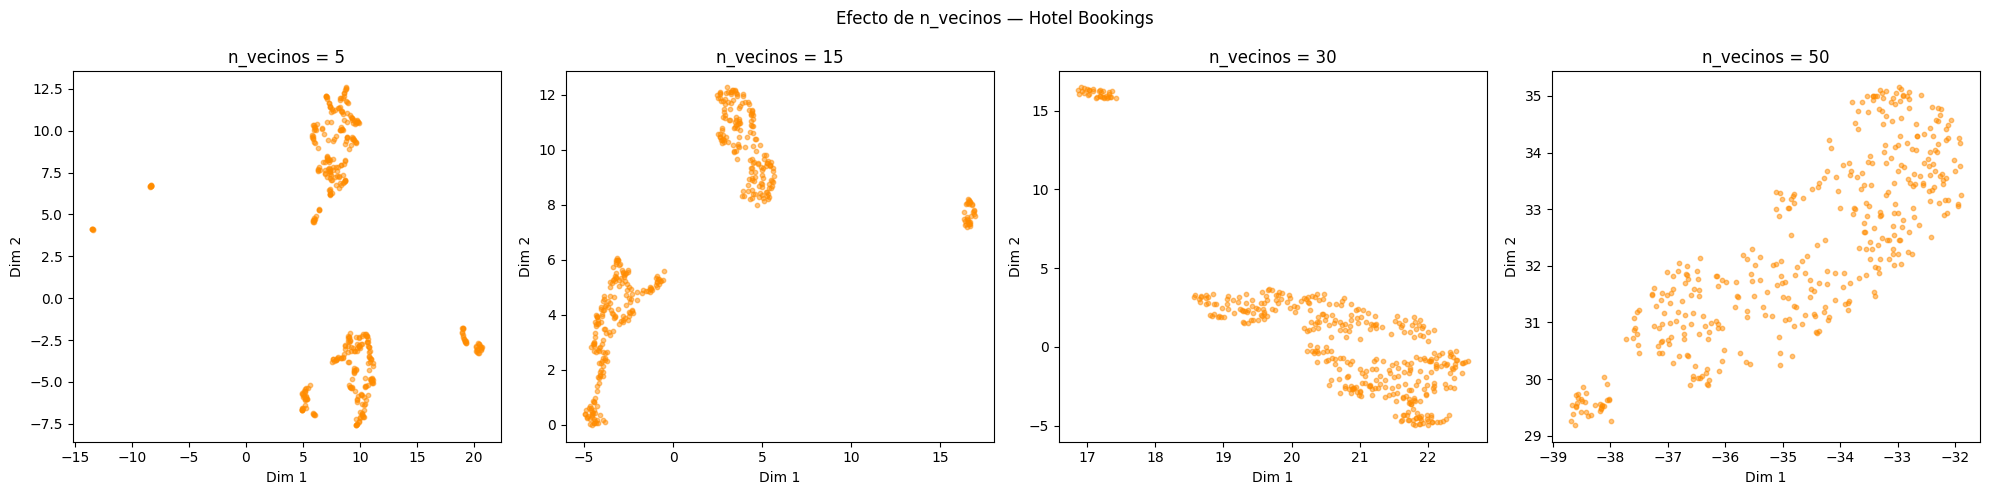

In [7]:
umap.plot_vecinos(valores=(5, 15, 30, 50), titulo='Efecto de n_vecinos — Hotel Bookings')
plt.show()

## 8. Conclusiones

- **`n_vecinos` bajo (5–15):** resalta agrupaciones locales densas.
- **`n_vecinos` alto (50+):** preserva mejor la estructura global del dataset.
- **`distancia_minima` baja (0.0–0.1):** puntos del mismo cluster quedan muy juntos.
- **`distancia_minima` alta (0.5–1.0):** proyección más dispersa y continua.
- A diferencia de t-SNE, UMAP permite proyectar **nuevos datos** con `umap.transformar(nuevos_datos)`.